In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("---All modules imported successfully---")

---All modules imported successfully---


In [2]:
pd.set_option("display.max_columns", None)

In [3]:
sns.set_style('whitegrid')

## Loading Dataset

In [4]:
df = pd.read_csv('../data/german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


## Dataset Exploration

In [5]:
# Get Size
import os

size_mb = os.path.getsize('../data/german_credit_data.csv') / (1024)
print(f'Size of Dataset: {size_mb:.1f}kB')

Size of Dataset: 52.1kB


In [6]:
df.shape

(1000, 11)

In [7]:
# Missing Values

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({"missing": missing, "pct": missing_pct}).sort_values("pct", ascending=False)

,missing,pct
Checking account,394,39.4
Saving accounts,183,18.3
Unnamed: 0,0,0.0
Sex,0,0.0
Age,0,0.0
Housing,0,0.0
Job,0,0.0
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0


In [8]:
# Duplicates

df.duplicated()          # True for rows that repeat an earlier row (all columns)
df.duplicated().sum()    # how many such rows exist

np.int64(0)

In [9]:
# Number of unique values in each field
df.nunique()

Unnamed: 0          1000
Age                   53
Sex                    2
Job                    4
Housing                3
Saving accounts        4
Checking account       3
Credit amount        921
Duration              33
Purpose                8
Risk                   2
dtype: int64

In [10]:
# datatype check

df.dtypes


Unnamed: 0          int64
Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
Risk                  str
dtype: object

In [11]:

# Summary

df.info()          # dtypes + non-null counts in one view
df.describe(include="all")   # stats for numeric AND categorical columns together

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [12]:
df['Sex'].value_counts()

Sex
male      690
female    310
Name: count, dtype: int64

In [13]:
df['Job'].value_counts()

Job
2    630
1    200
3    148
0     22
Name: count, dtype: int64

In [14]:
df['Housing'].value_counts()

Housing
own     713
rent    179
free    108
Name: count, dtype: int64

In [15]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

## Cleaning Dataset

In [16]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [17]:
df = df.dropna().reset_index(drop=True)
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [18]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [19]:
df.drop(columns= 'Unnamed: 0', inplace = True)
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


## Graphical Analysis

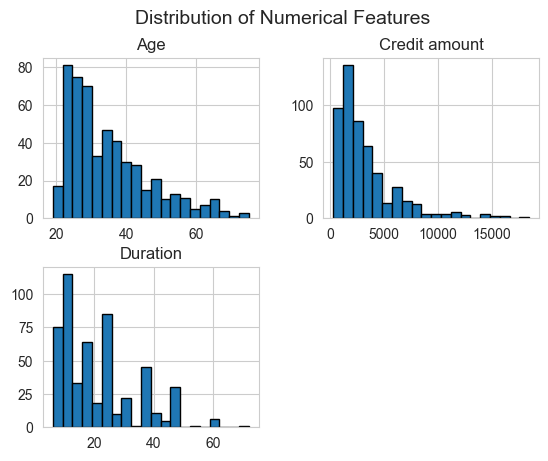

In [20]:
df[['Age', 'Credit amount', 'Duration']].hist(bins = 20, edgecolor = 'black')
plt.suptitle("Distribution of Numerical Features", fontsize = 14)
plt.show()

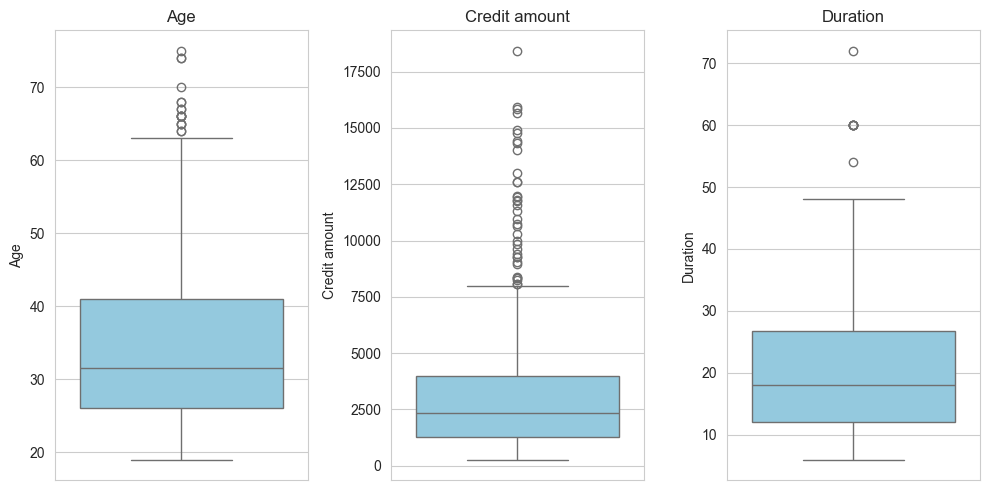

In [21]:
plt.figure(figsize = (10, 5))
for  i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y = df[col], color = 'skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [22]:
df.query('Duration >= 70')


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [23]:
df.query('Duration >= 50')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
54,58,male,2,rent,little,moderate,15945,54,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [24]:
df.query('Age >= 65')


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
42,66,male,3,free,little,little,1526,12,car,good
76,66,male,1,own,quite rich,moderate,766,12,radio/TV,bad
92,70,male,3,free,little,moderate,7308,10,car,good
102,65,male,2,own,little,little,571,21,car,good
105,74,female,3,free,little,moderate,5129,9,car,bad
106,68,male,0,free,little,moderate,1175,16,car,good
121,66,male,3,own,little,rich,1908,30,business,bad
175,75,male,3,free,little,little,6615,24,car,good
224,65,male,0,own,little,little,3394,42,repairs,good
289,67,female,3,own,little,moderate,1199,9,education,good


In [25]:
df.shape

(522, 10)

In [26]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


In [27]:
categorical_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

C:\Users\ujjaw\AppData\Local\Temp\ipykernel_23516\2452729775.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x = col, palette="Set2", order = df[col].value_counts().index)
C:\Users\ujjaw\AppData\Local\Temp\ipykernel_23516\2452729775.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x = col, palette="Set2", order = df[col].value_counts().index)
C:\Users\ujjaw\AppData\Local\Temp\ipykernel_23516\2452729775.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x = col, palette="Set2", order = df[col].value

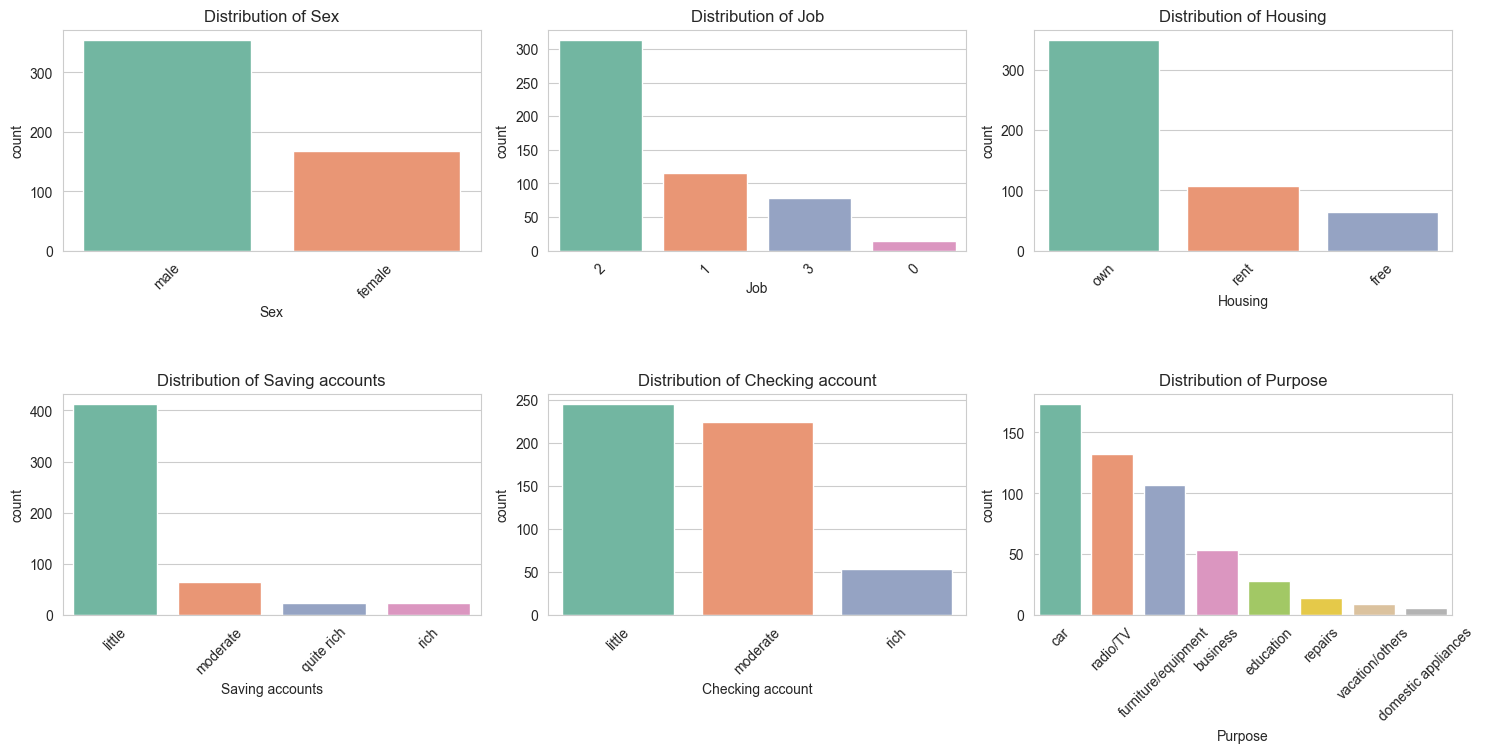

In [28]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data= df, x = col, palette="Set2", order = df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()


In [29]:
df.groupby('Job')['Credit amount'].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [30]:
pd.pivot_table(df, values = 'Credit amount', index = "Housing", columns= 'Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


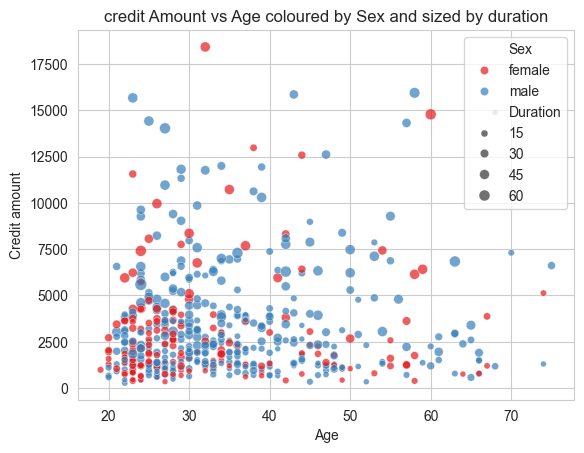

In [31]:
sns.scatterplot(data = df, x = 'Age', y = 'Credit amount', hue='Sex', size = "Duration", alpha = 0.7, palette = 'Set1')
plt.title('credit Amount vs Age coloured by Sex and sized by duration')
plt.show()

C:\Users\ujjaw\AppData\Local\Temp\ipykernel_23516\665945353.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Saving accounts', y = 'Credit amount', palette = 'Pastel1')


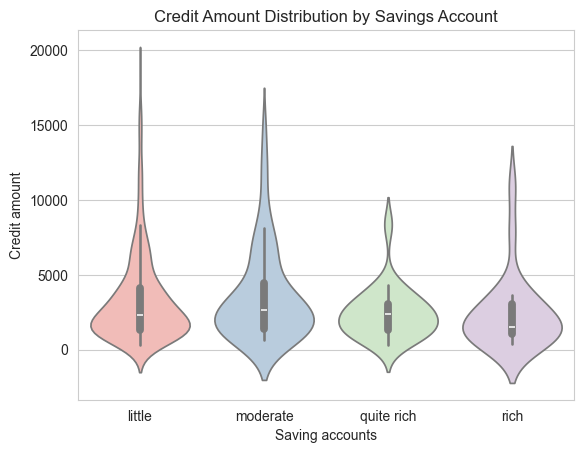

In [32]:
sns.violinplot(data=df, x='Saving accounts', y = 'Credit amount', palette = 'Pastel1')
plt.title('Credit Amount Distribution by Savings Account')
plt.show()

In [33]:
df['Risk'].value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

C:\Users\ujjaw\AppData\Local\Temp\ipykernel_23516\4197383043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df, x = 'Risk', y = col, palette= 'Pastel2')
C:\Users\ujjaw\AppData\Local\Temp\ipykernel_23516\4197383043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df, x = 'Risk', y = col, palette= 'Pastel2')
C:\Users\ujjaw\AppData\Local\Temp\ipykernel_23516\4197383043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df, x = 'Risk', y = col, palette= 'Pastel2')


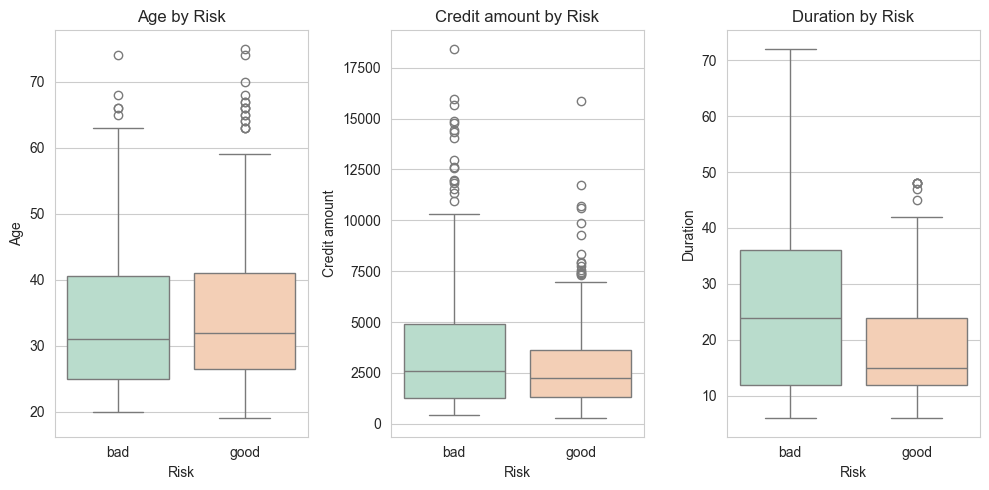

In [34]:
plt.figure(figsize = (10, 5))
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data= df, x = 'Risk', y = col, palette= 'Pastel2')
    plt.title(f'{col} by Risk')

plt.tight_layout()
plt.show()

In [35]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

## Feature Engineering

In [36]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [37]:
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration']

target = 'Risk'

In [38]:
df_model = df[features + [target]].copy()

In [39]:
df_model

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad
...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,good
518,30,male,3,own,little,little,3959,36,good
519,40,male,3,own,little,little,3857,30,good
520,23,male,2,free,little,little,1845,45,bad


### Encoding

In [40]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [41]:
cat_cols = df_model.select_dtypes(include=['object', 'string']).columns.drop("Risk")

# Label Encoder Dictionary
le_dict = {}

cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [42]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

    joblib.dump(le, f"{col}_encoder.pkl")

In [43]:
le_target = LabelEncoder()

df_model[target] = le_target.fit_transform(df_model[target])

df_model[target]
# 0 -> Bad (Higher Risk) ; 1 -> Good (Low Risk)

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [44]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [45]:
joblib.dump(le_target, 'target_encoder.pkl')

['target_encoder.pkl']

In [46]:
df_model.head(15)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0
5,25,0,2,2,0,1,1295,12,0
6,24,0,2,2,0,0,4308,48,0
7,22,0,2,1,0,1,1567,12,1
8,60,1,1,1,0,0,1199,24,0
9,28,0,2,2,0,0,1403,15,1


In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X = df_model.drop(target, axis = 1)
y = df_model[target]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, stratify=y, random_state=1)

In [50]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(365, 8)
(157, 8)
(365,)
(157,)


In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier 
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [52]:
def train_model(model, param_grid, X_train, X_test, y_train, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    return best_model, acc, grid.best_params_


In [53]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state = 1, class_weight = 'balanced')
dt_param_grid = {
    'max_depth' : [3, 5, 7, 10, None],
    'min_samples_split' : [2, 5, 10], 
    'min_samples_leaf' : [1, 2, 4]
}

In [54]:
best_dc, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, X_test, y_train, y_test)

print("Best parameters", params_dt)
print(f'Decision Tree Accuracy: {acc_dt}')


Best parameters {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Decision Tree Accuracy: 0.6242038216560509


In [55]:
# Random Forest Classifier

rf = RandomForestClassifier(random_state = 1, class_weight = 'balanced', n_jobs=-1)
rf_param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [3, 5, 7, 10, None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

In [56]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, X_test, y_train, y_test)

e:\Mini Project\credit_score_analyzer\.venv\Lib\site-packages\numpy\ma\core.py:2895: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [57]:
print('Best parameters', params_rf)
print(f'Random Forest Accuracy: {acc_rf}')


Best parameters {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Random Forest Accuracy: 0.6560509554140127


In [58]:
# extra trees classifier

et = ExtraTreesClassifier(random_state = 1, class_weight = 'balanced', n_jobs=-1)

et_param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [3, 5, 7, 10, None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

In [59]:
best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, X_test, y_train, y_test)

In [60]:
print("Best parameters", params_et)
print(f'Extra Trees Accuracy: {acc_et}')


Best parameters {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Extra Trees Accuracy: 0.6496815286624203


In [61]:
# XGBoost Classifier

xgb = XGBClassifier(random_state = 1, scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(), use_label_encoder=False, eval_metric='logloss')

In [62]:
xgb_param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [3, 5, 7, 10],
    'learning_rate' : [0.01, 0.1, 0.2],
    'subsample' : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0]
}

In [63]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, X_test, y_train, y_test)

e:\Mini Project\credit_score_analyzer\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:38:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [64]:
print("Best parameters", params_xgb)
print(f'XGBoost Accuracy: {acc_xgb}')

Best parameters {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
XGBoost Accuracy: 0.6050955414012739


In [66]:
best_rf.predict(X_test)

array([1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1])

## Exporting pkl model

In [67]:
joblib.dump(best_rf, "random_forest_credit_model.pkl")

['random_forest_credit_model.pkl']